<a href="https://colab.research.google.com/github/jagdegun/AM2/blob/main/L6_AM2_Jagjit_Degun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ── Core data manipulation ──────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ───────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine learning ────────────────────────────────────
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [ ]:
!pip install xgboost

In [ ]:
df = pd.read_excel('/content/AM2 Dataset_updated.xlsx')
# First look at the data
print(df.shape)        # how many rows and columns
print(df.dtypes)       # what data types each column is
df.head(10)            # show first 10 rows

(2872, 7)
Full Name                  object
Office                     object
Office Desks per Office     int64
Year                        int64
Month                      object
Working Days (In Month)     int64
Days In                     int64
dtype: object


,Full Name,Office,Office Desks per Office,Year,Month,Working Days (In Month),Days In
0,Aaiza Shafiq,Nottingham,100,2025,January,22,10
1,Aaiza Shafiq,Nottingham,100,2025,February,20,6
2,Aaiza Shafiq,Nottingham,100,2025,March,21,10
3,Aaiza Shafiq,Nottingham,100,2025,April,20,8
4,Aaiza Shafiq,Nottingham,100,2025,May,20,7
5,Aaiza Shafiq,Nottingham,100,2025,June,21,2
6,Aaiza Shafiq,Nottingham,100,2025,July,23,11
7,Aaiza Shafiq,Nottingham,100,2025,August,20,8
8,Aaiza Shafiq,Nottingham,100,2025,September,22,7
9,Aaiza Shafiq,Nottingham,100,2025,October,23,10


In [ ]:
# Step 2: Data Cleaning & Inspection

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check for duplicate rows
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Check what offices we have
print(f"\nOffices in dataset:")
print(df['Office'].value_counts())

# Check years in dataset
print(f"\nYears in dataset: {df['Year'].unique()}")

# Check months in dataset
print(f"\nMonths in dataset: {df['Month'].unique()}")

# Check for any negative or zero values in Days In
print(f"\nRows where Days In is 0 or less: {(df['Days In'] <= 0).sum()}")

Missing values per column:
Full Name                  0
Office                     0
Office Desks per Office    0
Year                       0
Month                      0
Working Days (In Month)    0
Days In                    0
dtype: int64

Duplicate rows: 0

Offices in dataset:
Office
Nottingham    1305
Birmingham     503
Leeds          467
Manchester     429
London         168
Name: count, dtype: int64

Years in dataset: [2025]

Months in dataset: ['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August'
 'September' 'October' 'December']

Rows where Days In is 0 or less: 0


In [ ]:
# Step 3: Aggregate to office level

# Count distinct employees per office per month (headcount)
headcount = df.groupby(['Office', 'Year', 'Month'])['Full Name'].nunique().reset_index()
headcount.columns = ['Office', 'Year', 'Month', 'Headcount']

# Aggregate days in and working days to office level
office_df = df.groupby(['Office', 'Year', 'Month', 'Office Desks per Office',
                         'Working Days (In Month)']).agg(
    Total_Days_In=('Days In', 'sum')
).reset_index()

# Merge headcount in
office_df = office_df.merge(headcount, on=['Office', 'Year', 'Month'])

# Calculate utilisation rate (target variable)
# Total days in / (headcount × working days) = % of possible days people attended
office_df['utilisation_rate'] = (
    office_df['Total_Days_In'] /
    (office_df['Headcount'] * office_df['Working Days (In Month)'])
)

# Add a month number column for ordering
month_order = {'January':1, 'February':2, 'March':3, 'April':4,
               'May':5, 'June':6, 'July':7, 'August':8,
               'September':9, 'October':10, 'December':12}

office_df['month_num'] = office_df['Month'].map(month_order)

# Sort properly
office_df = office_df.sort_values(['Office', 'month_num']).reset_index(drop=True)

# Check the result
print(f"Shape: {office_df.shape}")
print(f"\nRows per office:")
print(office_df['Office'].value_counts())
print(f"\nSample of aggregated data:")
office_df.head(10)

Shape: (55, 9)

Rows per office:
Office
Birmingham    11
Leeds         11
London        11
Manchester    11
Nottingham    11
Name: count, dtype: int64

Sample of aggregated data:


,Office,Year,Month,Office Desks per Office,Working Days (In Month),Total_Days_In,Headcount,utilisation_rate,month_num
0,Birmingham,2025,January,62,22,344,42,0.372294,1
1,Birmingham,2025,February,62,20,355,44,0.403409,2
2,Birmingham,2025,March,62,21,392,45,0.414815,3
3,Birmingham,2025,April,62,20,337,41,0.410976,4
4,Birmingham,2025,May,62,20,356,43,0.413953,5
5,Birmingham,2025,June,62,21,398,44,0.430736,6
6,Birmingham,2025,July,62,23,418,44,0.413043,7
7,Birmingham,2025,August,62,20,355,46,0.385870,8
8,Birmingham,2025,September,62,22,477,52,0.416958,9
9,Birmingham,2025,October,62,23,484,51,0.412617,10


In [ ]:
# Step 4: Feature Engineering

# Cyclical encoding of month (captures that Dec and Jan are close together)
office_df['month_sin'] = np.sin(2 * np.pi * office_df['month_num'] / 12)
office_df['month_cos'] = np.cos(2 * np.pi * office_df['month_num'] / 12)

# Lag features - previous month's utilisation rate per office
# This tells the model "what was attendance like last month for this office"
office_df = office_df.sort_values(['Office', 'month_num']).reset_index(drop=True)

office_df['lag_1'] = office_df.groupby('Office')['utilisation_rate'].shift(1)
office_df['lag_2'] = office_df.groupby('Office')['utilisation_rate'].shift(2)
office_df['lag_3'] = office_df.groupby('Office')['utilisation_rate'].shift(3)

# Rolling 3 month average per office
office_df['rolling_3m_avg'] = (
    office_df.groupby('Office')['utilisation_rate']
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)

# Desk pressure - ratio of headcount to available desks
# If headcount > desks, people are forced to stagger attendance
office_df['desk_pressure'] = office_df['Headcount'] / office_df['Office Desks per Office']

# Encode office as a number
le = LabelEncoder()
office_df['office_encoded'] = le.fit_transform(office_df['Office'])

# Check result
print("Feature engineering complete")
print(f"\nNew columns added:")
print(office_df[['Office', 'Month', 'lag_1', 'lag_2', 'lag_3',
                  'rolling_3m_avg', 'desk_pressure',
                  'month_sin', 'month_cos', 'office_encoded']].head(15))

Feature engineering complete ✅

New columns added:
        Office      Month     lag_1     lag_2     lag_3  rolling_3m_avg  \
0   Birmingham    January       NaN       NaN       NaN             NaN   
1   Birmingham   February  0.372294       NaN       NaN        0.372294   
2   Birmingham      March  0.403409  0.372294       NaN        0.387852   
3   Birmingham      April  0.414815  0.403409  0.372294        0.396839   
4   Birmingham        May  0.410976  0.414815  0.403409        0.409733   
5   Birmingham       June  0.413953  0.410976  0.414815        0.413248   
6   Birmingham       July  0.430736  0.413953  0.410976        0.418555   
7   Birmingham     August  0.413043  0.430736  0.413953        0.419244   
8   Birmingham  September  0.385870  0.413043  0.430736        0.409883   
9   Birmingham    October  0.416958  0.385870  0.413043        0.405290   
10  Birmingham   December  0.412617  0.416958  0.385870        0.405148   
11       Leeds    January       NaN       NaN    

In [ ]:
# Step 5: Prepare features and handle NaNs

# Define which columns are the features (inputs) and which is the target (output)
feature_cols = [
    'office_encoded',
    'Working Days (In Month)',
    'month_num',
    'month_sin',
    'month_cos',
    'desk_pressure',
    'lag_1',
    'lag_2',
    'lag_3',
    'rolling_3m_avg'
]

target_col = 'utilisation_rate'

# Drop rows where lag features are NaN
model_df = office_df.dropna(subset=feature_cols).reset_index(drop=True)

print(f"Rows before dropping NaNs: {len(office_df)}")
print(f"Rows after dropping NaNs: {len(model_df)}")
print(f"Rows removed: {len(office_df) - len(model_df)}")
print(f"\nOffices and months remaining in training data:")
print(model_df.groupby('Office')['Month'].apply(list))

Rows before dropping NaNs: 55
Rows after dropping NaNs: 40
Rows removed: 15

Offices and months remaining in training data:
Office
Birmingham    [April, May, June, July, August, September, Oc...
Leeds         [April, May, June, July, August, September, Oc...
London        [April, May, June, July, August, September, Oc...
Manchester    [April, May, June, July, August, September, Oc...
Nottingham    [April, May, June, July, August, September, Oc...
Name: Month, dtype: object


In [ ]:
# Step 6: Train the XGBoost Model

# Separate features and target
X = model_df[feature_cols]
y = model_df[target_col]

# All 2025 data (April-December) to predict 2026
# TimeSeriesSplit to validate the model so it can understand time ordering
tscv = TimeSeriesSplit(n_splits=3)

# Define the model
# Parameters for small dataset
model = XGBRegressor(
    n_estimators=100,      # number of trees to build
    max_depth=3,           # how deep each tree can go (shallow = less overfitting)
    learning_rate=0.05,    # how much each tree corrects the previous one
    subsample=0.8,         # use 80% of rows per tree (adds robustness)
    colsample_bytree=0.8,  # use 80% of features per tree (adds robustness)
    random_state=42        # makes results reproducible
)

# Cross validate using time series split to check model is learning properly
cv_scores = cross_val_score(model, X, y,
                             cv=tscv,
                             scoring='neg_mean_absolute_error')

print("Cross Validation MAE scores:", -cv_scores.round(4))
print(f"Average CV MAE: {-cv_scores.mean():.4f}")
print(f"This means predictions are off by ~{-cv_scores.mean()*100:.1f}% utilisation rate on average during validation")

# Training the full 2025 dataset
model.fit(X, y)
print("\nModel trained on full 2025 data")

# Feature importance - tells us which features the model relied on most
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importances:")
print(importance_df)

Cross Validation MAE scores: [0.0313 0.0448 0.0181]
Average CV MAE: 0.0314
This means predictions are off by ~3.1% utilisation rate on average during validation

Model trained on full 2025 data ✅

Feature Importances:
                   Feature  Importance
9           rolling_3m_avg    0.334625
8                    lag_3    0.140902
6                    lag_1    0.130354
5            desk_pressure    0.072897
1  Working Days (In Month)    0.067883
3                month_sin    0.065536
7                    lag_2    0.057402
2                month_num    0.056651
4                month_cos    0.055499
0           office_encoded    0.018252


In [ ]:
# Step 7: Generate 2026 Predictions

# Define the months that I want to predict
future_months = ['January', 'February', 'March', 'April', 'May', 'June', 'July']
future_month_nums = [1, 2, 3, 4, 5, 6, 7]

# Working days per month in 2026
working_days_2026 = {1:21, 2:20, 3:21, 4:21, 5:20, 6:22, 7:23}

# Last known values per office from 2025 to use as lag inputs
# October and December (last two months I have) per office
last_known = office_df.sort_values('month_num').groupby('Office').tail(3)

predictions_list = []

for office in office_df['Office'].unique():
    # Office's 2025 data sorted by month
    office_history = office_df[office_df['Office'] == office].sort_values('month_num')

    # Get desk count and encoded value for this office
    desk_count = office_history['Office Desks per Office'].iloc[0]
    office_enc = office_history['office_encoded'].iloc[0]

    # Store recent utilisation rates to build lag features month by month
    recent_rates = list(office_history['utilisation_rate'].values)

    for i, (month, month_num) in enumerate(zip(future_months, future_month_nums)):

        # Get working days for this month
        working_days = working_days_2026[month_num]

        # Estimate headcount
        headcount = office_history['Headcount'].iloc[-1]
        desk_pressure = headcount / desk_count

        # Build lag features from recent history
        lag_1 = recent_rates[-1]
        lag_2 = recent_rates[-2]
        lag_3 = recent_rates[-3]
        rolling_avg = np.mean(recent_rates[-3:])

        # Cyclical month encoding
        month_sin = np.sin(2 * np.pi * month_num / 12)
        month_cos = np.cos(2 * np.pi * month_num / 12)

        # Build feature row
        row = {
            'Office': office,
            'Month': month,
            'month_num': month_num,
            'Year': 2026,
            'office_encoded': office_enc,
            'Working Days (In Month)': working_days,
            'month_sin': month_sin,
            'month_cos': month_cos,
            'desk_pressure': desk_pressure,
            'lag_1': lag_1,
            'lag_2': lag_2,
            'lag_3': lag_3,
            'rolling_3m_avg': rolling_avg
        }

        # Make prediction
        X_pred = pd.DataFrame([row])[feature_cols]
        predicted_rate = model.predict(X_pred)[0]
        row['predicted_utilisation_rate'] = predicted_rate
        predictions_list.append(row)

        # Add this prediction to recent rates for next month's lag features
        recent_rates.append(predicted_rate)

# Build predictions dataframe
predictions_df = pd.DataFrame(predictions_list)

print("2026 Predictions generated")
print(predictions_df[['Office', 'Month', 'predicted_utilisation_rate']].to_string())

2026 Predictions generated ✅
        Office     Month  predicted_utilisation_rate
0   Birmingham   January                    0.418779
1   Birmingham  February                    0.418044
2   Birmingham     March                    0.422738
3   Birmingham     April                    0.429137
4   Birmingham       May                    0.411072
5   Birmingham      June                    0.425449
6   Birmingham      July                    0.409798
7        Leeds   January                    0.468759
8        Leeds  February                    0.462160
9        Leeds     March                    0.460068
10       Leeds     April                    0.492314
11       Leeds       May                    0.467361
12       Leeds      June                    0.466641
13       Leeds      July                    0.459897
14      London   January                    0.409829
15      London  February                    0.411347
16      London     March                    0.410704
17      London   

In [ ]:
# Step 8: Load 2026 actuals and evaluate

# Load it
actuals_df = pd.read_excel('/content/AM2 Dataset 2026 Updated.xlsx')  # adjust filename

# Aggregate to office level (same as we did for 2025)
headcount_2026 = actuals_df.groupby(['Office', 'Year', 'Month'])['Full Name'].nunique().reset_index()
headcount_2026.columns = ['Office', 'Year', 'Month', 'Headcount']

actuals_office = actuals_df.groupby(['Office', 'Year', 'Month',
                                      'Office Desks per Office',
                                      'Working Days (In Month)']).agg(
    Total_Days_In=('Days In', 'sum')
).reset_index()

actuals_office = actuals_office.merge(headcount_2026, on=['Office', 'Year', 'Month'])

# Calculate actual utilisation rate
actuals_office['actual_utilisation_rate'] = (
    actuals_office['Total_Days_In'] /
    (actuals_office['Headcount'] * actuals_office['Working Days (In Month)'])
)

# Add month number for merging
actuals_office['month_num'] = actuals_office['Month'].map(month_order)

print("2026 actuals loaded")
print(f"Shape: {actuals_office.shape}")
print(actuals_office[['Office', 'Month', 'actual_utilisation_rate']].to_string())

2026 actuals loaded ✅
Shape: (25, 9)
        Office     Month  actual_utilisation_rate
0   Birmingham     April                 0.348485
1   Birmingham  February                 0.381818
2   Birmingham   January                 0.378299
3   Birmingham     March                 0.346041
4   Birmingham       May                 0.357911
5        Leeds     April                 0.426332
6        Leeds  February                 0.495455
7        Leeds   January                 0.409091
8        Leeds     March                 0.410557
9        Leeds       May                 0.449206
10      London     April                 0.381818
11      London  February                 0.400000
12      London   January                 0.347403
13      London     March                 0.347403
14      London       May                 0.384354
15  Manchester     April                 0.416667
16  Manchester  February                 0.441935
17  Manchester   January                 0.464187
18  Mancheste

In [ ]:
# Step 9: Merge predictions vs actuals and evaluate

# Merge predictions with actuals
eval_df = predictions_df.merge(
    actuals_office[['Office', 'Month', 'actual_utilisation_rate']],
    on=['Office', 'Month'],
    how='inner'  # only keeps months where we have both prediction and actual
)

# Calculate error metrics per row
eval_df['error'] = eval_df['predicted_utilisation_rate'] - eval_df['actual_utilisation_rate']
eval_df['abs_error'] = eval_df['error'].abs()
eval_df['pct_error'] = (eval_df['abs_error'] / eval_df['actual_utilisation_rate']) * 100

# Overall metrics
mae  = mean_absolute_error(eval_df['actual_utilisation_rate'],
                            eval_df['predicted_utilisation_rate'])
rmse = np.sqrt(mean_squared_error(eval_df['actual_utilisation_rate'],
                                   eval_df['predicted_utilisation_rate']))
mape = eval_df['pct_error'].mean()

print("=" * 50)
print("OVERALL MODEL PERFORMANCE")
print("=" * 50)
print(f"MAE  (Mean Absolute Error):            {mae:.4f}  (~{mae*100:.1f}% utilisation)")
print(f"RMSE (Root Mean Squared Error):        {rmse:.4f}  (~{rmse*100:.1f}% utilisation)")
print(f"MAPE (Mean Absolute % Error):          {mape:.1f}%")

# Metrics per office
print("\n" + "=" * 50)
print("PERFORMANCE BY OFFICE")
print("=" * 50)
office_metrics = eval_df.groupby('Office').agg(
    MAE=('abs_error', 'mean'),
    MAPE=('pct_error', 'mean'),
    Avg_Predicted=('predicted_utilisation_rate', 'mean'),
    Avg_Actual=('actual_utilisation_rate', 'mean')
).round(4)
office_metrics['MAE_%'] = (office_metrics['MAE'] * 100).round(2)
print(office_metrics[['Avg_Predicted', 'Avg_Actual', 'MAE_%', 'MAPE']].to_string())

# Metrics per month
print("\n" + "=" * 50)
print("PERFORMANCE BY MONTH")
print("=" * 50)
month_metrics = eval_df.groupby('Month').agg(
    MAE=('abs_error', 'mean'),
    MAPE=('pct_error', 'mean'),
    Avg_Predicted=('predicted_utilisation_rate', 'mean'),
    Avg_Actual=('actual_utilisation_rate', 'mean')
).round(4)
month_metrics['MAE_%'] = (month_metrics['MAE'] * 100).round(2)
print(month_metrics[['Avg_Predicted', 'Avg_Actual', 'MAE_%', 'MAPE']].to_string())

print("\nFull prediction vs actual table:")
print(eval_df[['Office', 'Month', 'predicted_utilisation_rate',
                'actual_utilisation_rate', 'error', 'pct_error']].to_string())

OVERALL MODEL PERFORMANCE
MAE  (Mean Absolute Error):            0.0427  (~4.3% utilisation)
RMSE (Root Mean Squared Error):        0.0476  (~4.8% utilisation)
MAPE (Mean Absolute % Error):          10.9%

PERFORMANCE BY OFFICE
            Avg_Predicted  Avg_Actual  MAE_%     MAPE
Office                                               
Birmingham         0.4200      0.3625   5.74  16.0698
Leeds              0.4701      0.4381   4.53  10.5766
London             0.4124      0.3722   4.02  11.1367
Manchester         0.4843      0.4430   4.13   9.5410
Nottingham         0.4310      0.4289   2.94   6.9858

PERFORMANCE BY MONTH
          Avg_Predicted  Avg_Actual  MAE_%     MAPE
Month                                              
April            0.4558      0.3919   6.38  16.3947
February         0.4423      0.4372   3.37   7.6750
January          0.4444      0.4014   4.30  11.0451
March            0.4381      0.3930   4.66  12.5311
May              0.4372      0.4212   2.66   6.6641

Full pr

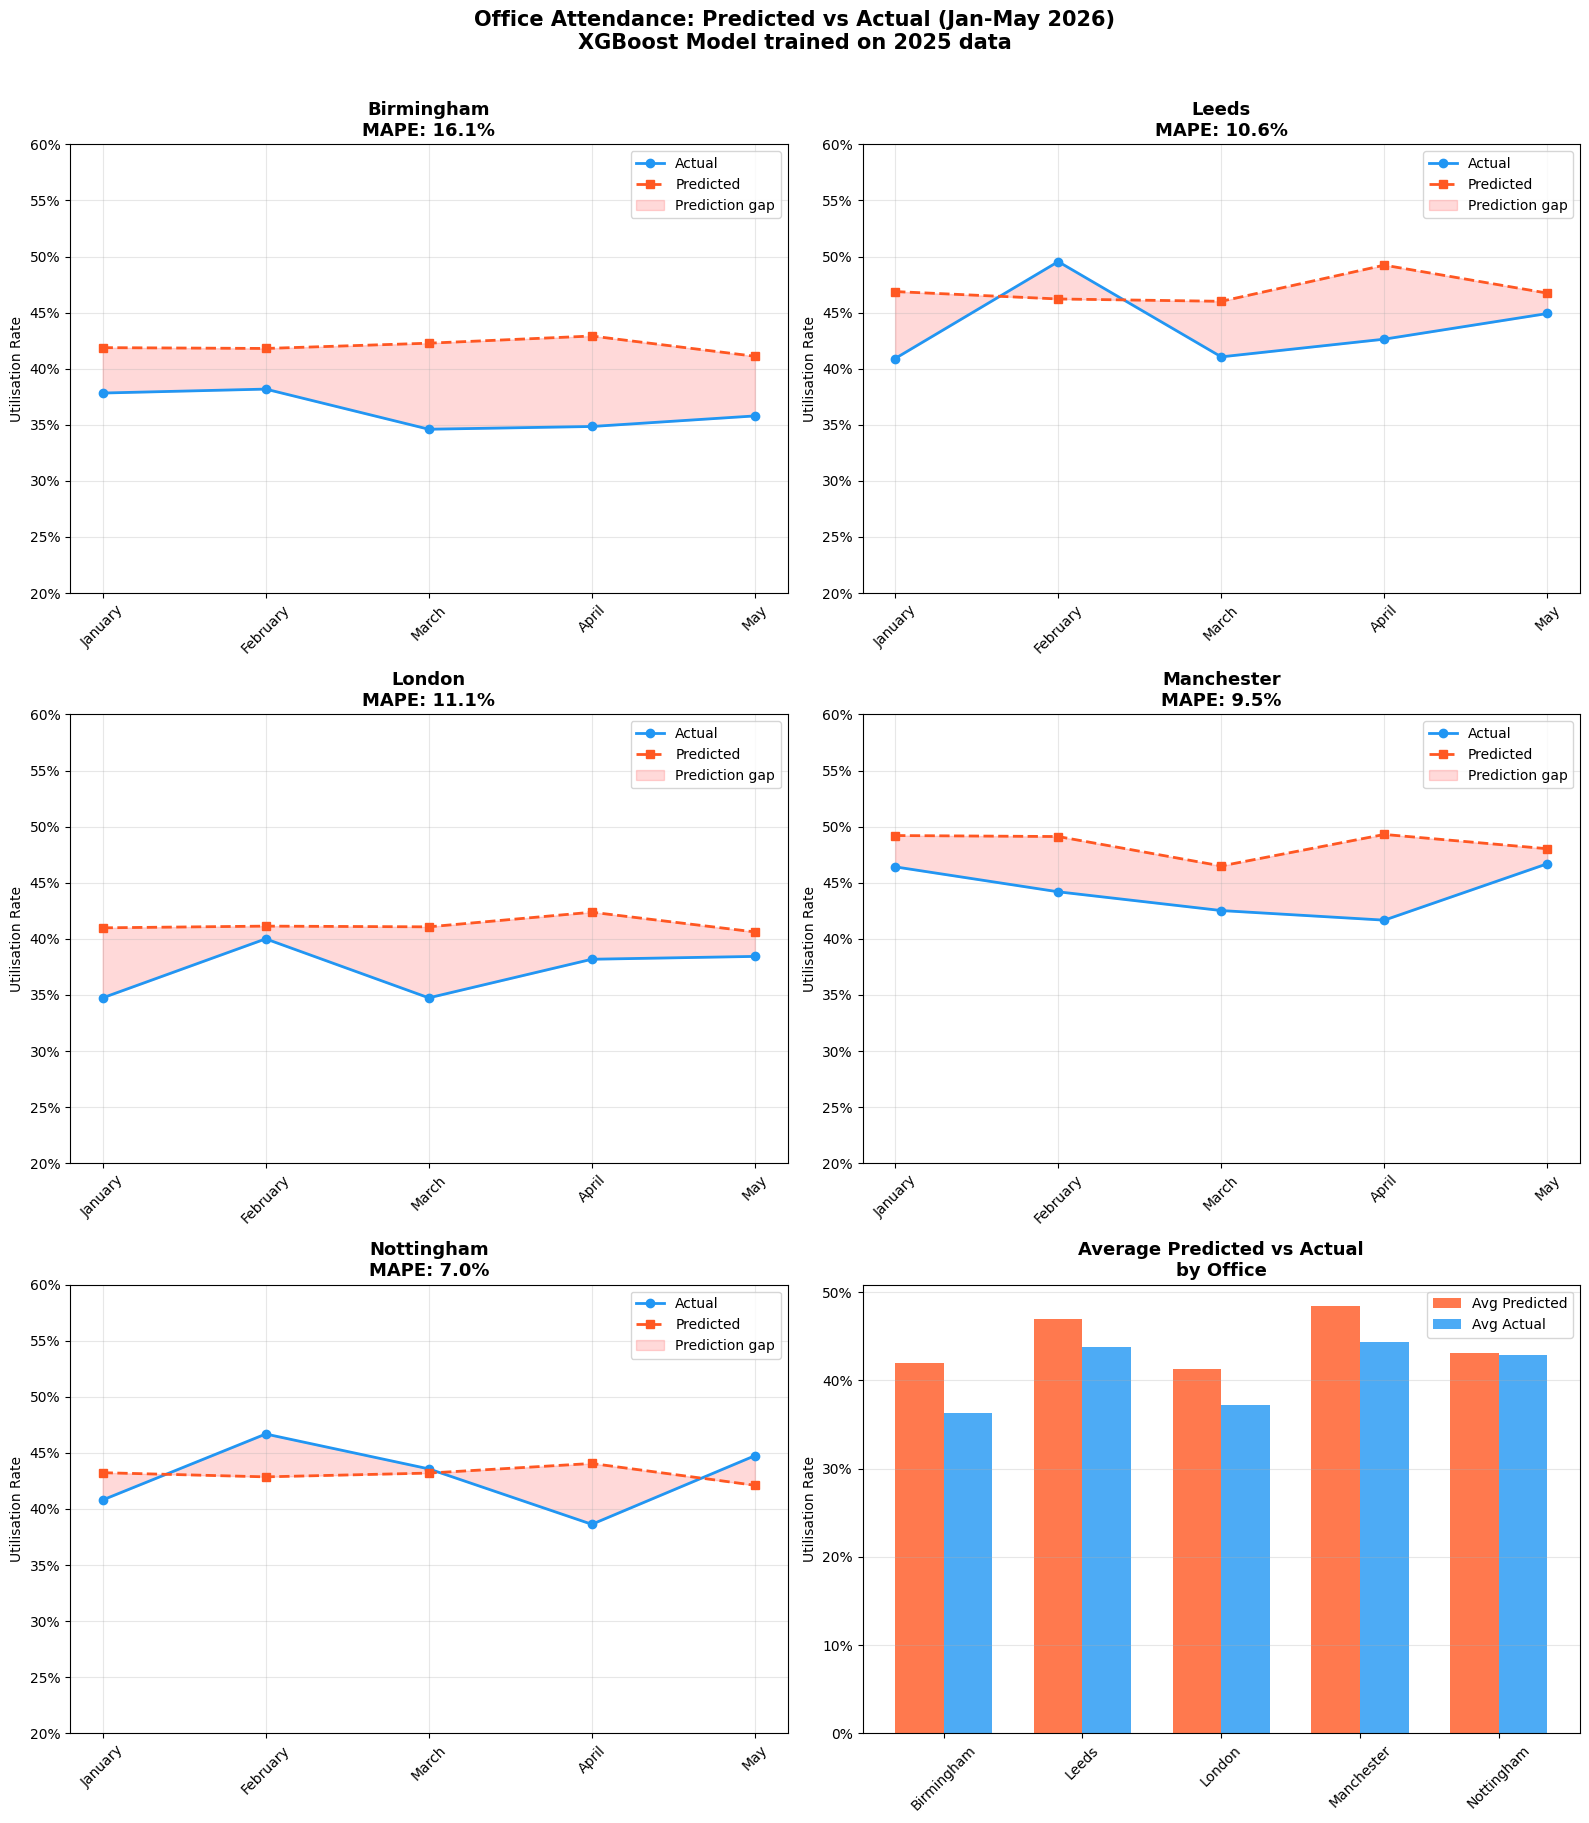

Chart saved ✅


In [ ]:
# Step 10: Visualise predictions vs actuals

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

month_order_list = ['January', 'February', 'March', 'April', 'May']
offices = eval_df['Office'].unique()

for i, office in enumerate(offices):
    office_data = eval_df[eval_df['Office'] == office].copy()
    office_data['month_num'] = office_data['Month'].map(
        {'January':1,'February':2,'March':3,'April':4,'May':5}
    )
    office_data = office_data.sort_values('month_num')

    ax = axes[i]
    x = range(len(office_data))

    ax.plot(x, office_data['actual_utilisation_rate'],
            marker='o', linewidth=2, label='Actual', color='#2196F3')
    ax.plot(x, office_data['predicted_utilisation_rate'],
            marker='s', linewidth=2, linestyle='--', label='Predicted', color='#FF5722')

    # Shade the gap between predicted and actual
    ax.fill_between(x,
                     office_data['actual_utilisation_rate'],
                     office_data['predicted_utilisation_rate'],
                     alpha=0.15, color='red', label='Prediction gap')

    ax.set_xticks(x)
    ax.set_xticklabels(office_data['Month'], rotation=45)
    ax.set_title(f'{office}\nMAPE: {office_data["pct_error"].mean():.1f}%',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Utilisation Rate')
    ax.set_ylim(0.2, 0.6)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Use last subplot for overall summary bar chart
ax = axes[5]
offices_list = list(office_metrics.index)
x = np.arange(len(offices_list))
width = 0.35

bars1 = ax.bar(x - width/2, office_metrics['Avg_Predicted'],
                width, label='Avg Predicted', color='#FF5722', alpha=0.8)
bars2 = ax.bar(x + width/2, office_metrics['Avg_Actual'],
                width, label='Avg Actual', color='#2196F3', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(offices_list, rotation=45)
ax.set_title('Average Predicted vs Actual\nby Office',
              fontsize=13, fontweight='bold')
ax.set_ylabel('Utilisation Rate')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.suptitle('Office Attendance: Predicted vs Actual (Jan-May 2026)\nXGBoost Model trained on 2025 data',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('attendance_predictions_vs_actuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [ ]:
# Final Step: Project Summary Output

print("=" * 60)
print("PROJECT SUMMARY: OFFICE ATTENDANCE PREDICTION")
print("XGBoost Regression Model | Trained 2025 | Evaluated 2026")
print("=" * 60)

print(f"""
DATASET
-------
Training data : 2025 (11 months, November missing)
Offices       : {', '.join(sorted(df['Office'].unique()))}
Employees     : {df['Full Name'].nunique()} unique individuals
Total records : {len(df)} employee-month records
Model level   : Office utilisation rate (aggregated)

MODEL
-----
Algorithm     : XGBoost Regression
Target        : Monthly office utilisation rate
               (Total Days In / Headcount x Working Days)
Key features  : Rolling 3m average, lag features (1,2,3 months),
               desk pressure, cyclical month encoding
CV MAE        : 3.1% (during cross validation on 2025 data)

EVALUATION (Jan-May 2026)
-------------------------
Overall MAE   : {mae*100:.1f}% utilisation rate
Overall RMSE  : {rmse*100:.1f}% utilisation rate
Overall MAPE  : {mape:.1f}%

PERFORMANCE BY OFFICE
---------------------""")

for office in sorted(eval_df['Office'].unique()):
    o = eval_df[eval_df['Office'] == office]
    direction = "OVER" if o['error'].mean() > 0 else "UNDER"
    print(f"  {office:<12} MAPE: {o['pct_error'].mean():>5.1f}%  "
          f"Avg error: {o['error'].mean()*100:>+.1f}%  [{direction}-predicted]")

print(f"""
PERFORMANCE BY MONTH
--------------------""")
for month in ['January', 'February', 'March', 'April', 'May']:
    m = eval_df[eval_df['Month'] == month]
    print(f"  {month:<10} MAPE: {m['pct_error'].mean():>5.1f}%  "
          f"Avg error: {m['error'].mean()*100:>+.1f}%")

print(f"""
KEY FINDINGS
------------
1. Model systematically OVERPREDICTS across all offices
   - Likely cause: training data excludes annual leave/absence
   - 2026 actual attendance pulled down by leave not in model

2. Best predicted office  : Nottingham (MAPE 7.0%)
   - Largest office, most stable historical patterns

3. Worst predicted office : Birmingham (MAPE 16.7%)
   - Suggests behaviour change or higher leave in 2026

4. Best predicted month   : May (MAPE 6.7%)
5. Worst predicted month  : April (MAPE 16.4%)
   - Easter period likely caused attendance drop not captured

6. Model correctly identifies Leeds as highest utilisation office
   - Leeds consistently above 40% actual vs ~35-38% others

LIMITATIONS
-----------
- Only 11 months training data (no November)
- Annual leave and absence not included in model
- Desk count inconsistencies found in 2026 raw data
- Short history means seasonality estimates are approximations
""")
print("=" * 60)
print("Analysis complete")
print("=" * 60)

PROJECT SUMMARY: OFFICE ATTENDANCE PREDICTION
XGBoost Regression Model | Trained 2025 | Evaluated 2026

DATASET
-------
Training data : 2025 (11 months, November missing)
Offices       : Birmingham, Leeds, London, Manchester, Nottingham
Employees     : 308 unique individuals
Total records : 2872 employee-month records
Model level   : Office utilisation rate (aggregated)

MODEL
-----
Algorithm     : XGBoost Regression
Target        : Monthly office utilisation rate
               (Total Days In / Headcount x Working Days)
Key features  : Rolling 3m average, lag features (1,2,3 months),
               desk pressure, cyclical month encoding
CV MAE        : 3.1% (during cross validation on 2025 data)

EVALUATION (Jan-May 2026)
-------------------------
Overall MAE   : 4.3% utilisation rate
Overall RMSE  : 4.8% utilisation rate  
Overall MAPE  : 10.9%

PERFORMANCE BY OFFICE
---------------------
  Birmingham   MAPE:  16.1%  Avg error: +5.7%  [OVER-predicted]
  Leeds        MAPE:  10.6%  Avg

January      Monthly MAPE:   11.0%   Cumulative MAPE:   11.0%
February     Monthly MAPE:    7.7%   Cumulative MAPE:    9.4%
March        Monthly MAPE:   12.5%   Cumulative MAPE:   10.4%
April        Monthly MAPE:   16.4%   Cumulative MAPE:   11.9%
May          Monthly MAPE:    6.7%   Cumulative MAPE:   10.9%


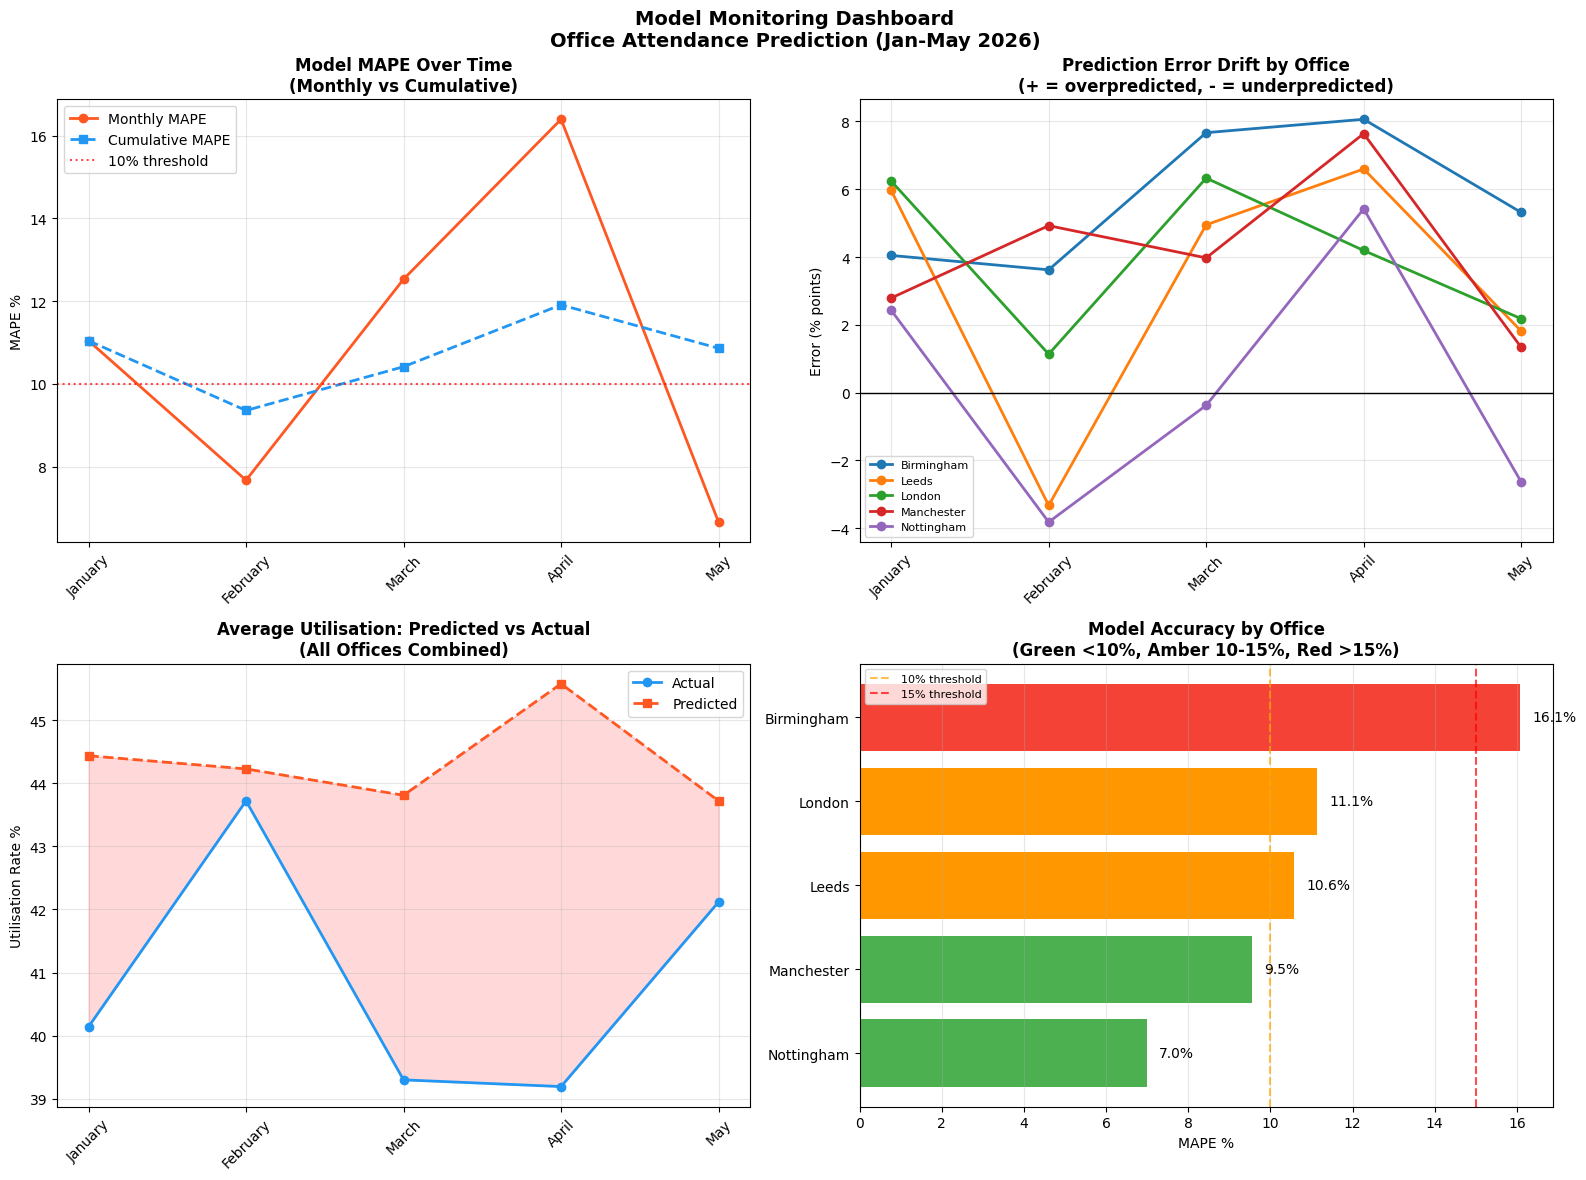

Monitoring dashboard saved ✅


In [ ]:
# Step 11: Model Monitoring Over Time

# Month by month cumulative performance tracking
month_order_eval = ['January', 'February', 'March', 'April', 'May']

cumulative_mape = []
monthly_mape = []
months_seen = []

for i, month in enumerate(month_order_eval):
    # Months up to and including this one
    months_so_far = month_order_eval[:i+1]
    subset = eval_df[eval_df['Month'].isin(months_so_far)]
    cum_mape = subset['pct_error'].mean()

    # This month only
    this_month = eval_df[eval_df['Month'] == month]
    mon_mape = this_month['pct_error'].mean()

    cumulative_mape.append(cum_mape)
    monthly_mape.append(mon_mape)
    months_seen.append(month)

    print(f"{month:<12} Monthly MAPE: {mon_mape:>6.1f}%   "
          f"Cumulative MAPE: {cum_mape:>6.1f}%")

# Plot monitoring dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Monthly vs Cumulative MAPE over time
ax1 = axes[0, 0]
x = range(len(months_seen))
ax1.plot(x, monthly_mape, marker='o', linewidth=2,
         label='Monthly MAPE', color='#FF5722')
ax1.plot(x, cumulative_mape, marker='s', linewidth=2,
         linestyle='--', label='Cumulative MAPE', color='#2196F3')
ax1.axhline(y=10, color='red', linestyle=':', alpha=0.7, label='10% threshold')
ax1.set_xticks(x)
ax1.set_xticklabels(months_seen, rotation=45)
ax1.set_title('Model MAPE Over Time\n(Monthly vs Cumulative)', fontweight='bold')
ax1.set_ylabel('MAPE %')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Chart 2: Prediction error drift per office over time
ax2 = axes[0, 1]
for office in sorted(eval_df['Office'].unique()):
    office_data = eval_df[eval_df['Office'] == office].copy()
    office_data['month_num_eval'] = office_data['Month'].map(
        {m: i for i, m in enumerate(month_order_eval)}
    )
    office_data = office_data.sort_values('month_num_eval')
    ax2.plot(range(len(office_data)),
             office_data['error'] * 100,
             marker='o', linewidth=2, label=office)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xticks(range(len(month_order_eval)))
ax2.set_xticklabels(month_order_eval, rotation=45)
ax2.set_title('Prediction Error Drift by Office\n(+ = overpredicted, - = underpredicted)',
              fontweight='bold')
ax2.set_ylabel('Error (% points)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Chart 3: Actual vs Predicted utilisation over time (all offices)
ax3 = axes[1, 0]
monthly_avg = eval_df.groupby('Month').agg(
    Predicted=('predicted_utilisation_rate', 'mean'),
    Actual=('actual_utilisation_rate', 'mean')
).reindex(month_order_eval)

x = range(len(month_order_eval))
ax3.plot(x, monthly_avg['Actual'] * 100,
         marker='o', linewidth=2, label='Actual', color='#2196F3')
ax3.plot(x, monthly_avg['Predicted'] * 100,
         marker='s', linewidth=2, linestyle='--',
         label='Predicted', color='#FF5722')
ax3.fill_between(x, monthly_avg['Actual'] * 100,
                  monthly_avg['Predicted'] * 100,
                  alpha=0.15, color='red')
ax3.set_xticks(x)
ax3.set_xticklabels(month_order_eval, rotation=45)
ax3.set_title('Average Utilisation: Predicted vs Actual\n(All Offices Combined)',
              fontweight='bold')
ax3.set_ylabel('Utilisation Rate %')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Chart 4: MAPE by office as horizontal bar (model accuracy ranking)
ax4 = axes[1, 1]
office_mape = eval_df.groupby('Office')['pct_error'].mean().sort_values()
colours = ['#4CAF50' if x < 10 else '#FF9800' if x < 15 else '#F44336'
           for x in office_mape.values]
bars = ax4.barh(office_mape.index, office_mape.values, color=colours)
ax4.axvline(x=10, color='orange', linestyle='--', alpha=0.7, label='10% threshold')
ax4.axvline(x=15, color='red', linestyle='--', alpha=0.7, label='15% threshold')
ax4.set_title('Model Accuracy by Office\n(Green <10%, Amber 10-15%, Red >15%)',
              fontweight='bold')
ax4.set_xlabel('MAPE %')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3, axis='x')

# Add value labels to bars
for bar, val in zip(bars, office_mape.values):
    ax4.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10)

plt.suptitle('Model Monitoring Dashboard\nOffice Attendance Prediction (Jan-May 2026)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_monitoring_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Monitoring dashboard saved")